<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

I0000 00:00:1786045556.719507   84608 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Corpus

Tres textos del siglo XIX argentino: *Facundo* (Sarmiento), *Una excursión a los indios ranqueles* (Mansilla) y *Martín Fierro* (Hernández). Combinados suman ~1.17M de caracteres. Comparten registro y vocabulario de época.

In [2]:
import os
import re

CORPUS_DIR = "corpus_ar"
FILES = [
    "sarmiento_facundo.txt",
    "lucio_mansilla.txt",
    "hernandez_martin_fierro.txt",
]

def clean_gutenberg(text: str) -> str:
    start = re.search(r"\*\*\* START OF.*?\*\*\*", text)
    end = re.search(r"\*\*\* END OF.*?\*\*\*", text)
    if start:
        text = text[start.end():]
    if end:
        text = text[:end.start()]
    return text.strip()

In [3]:
texts = []
for name in FILES:
    path = os.path.join(CORPUS_DIR, name)
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read()
    clean = clean_gutenberg(raw)
    print(f"{name}: {len(clean):,} characters")
    texts.append(clean)

article_text = "\n".join(texts).lower()

print(f"\nCorpus total: {len(article_text):,} caracteres")


sarmiento_facundo.txt: 602,863 characters
lucio_mansilla.txt: 506,091 characters
hernandez_martin_fierro.txt: 67,297 characters

Corpus total: 1,176,253 caracteres


In [4]:
chars_vocab = set(article_text)
len(chars_vocab)
print(sorted(chars_vocab))


['\n', ' ', '!', '"', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '=', '?', '[', ']', '^', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '}', '¡', 'ª', '«', 'º', '»', '¿', 'à', 'á', 'â', 'æ', 'è', 'é', 'ê', 'ë', 'í', 'î', 'ï', 'ñ', 'ó', 'ù', 'ú', 'ü', 'œ', 'ά', 'γ', 'η', 'κ', 'ν', 'ἀ', '—', '™']


El vocabulario crudo tiene 89 caracteres, muchos con menos de 20 apariciones: letras griegas de alguna cita, variantes tipográficas, acentos no españoles. Se descartan para quedarnos con un vocabulario limpio de 64 símbolos.

In [5]:
from collections import Counter

MIN_FREQ = 20

char_counts = Counter(article_text)
raros = {ch: n for ch, n in char_counts.items() if n < MIN_FREQ}
print(f"Caracteres por debajo del umbral ({len(raros)}):")
for ch, n in sorted(raros.items(), key=lambda x: x[1]):
    print(repr(ch), n)

Caracteres por debajo del umbral (25):
'î' 1
'ï' 1
'ù' 1
'ë' 1
'œ' 1
'ἀ' 1
'ν' 1
'ά' 1
'γ' 1
'κ' 1
'η' 1
'æ' 2
'=' 2
'^' 2
'{' 2
'/' 3
'—' 3
'â' 4
'ª' 4
'}' 5
'ê' 6
'™' 6
'à' 10
'"' 10
'è' 19


In [6]:
chars_to_drop = set(raros.keys())

article_text_clean = "".join(ch for ch in article_text if ch not in chars_to_drop)

print(f"Caracteres eliminados: {len(chars_to_drop)}")
print(f"Longitud original: {len(article_text):,}")
print(f"Longitud limpia:   {len(article_text_clean):,}")

article_text = article_text_clean
chars_vocab = set(article_text)
len(chars_vocab)

Caracteres eliminados: 25
Longitud original: 1,176,253
Longitud limpia:   1,176,164


64

In [7]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

'produced by adrian mastronardi, chuck greif and the online\ndistributed proofreading team at http:www.pgdp.net (this\nfile was produced from images generously made available\nby the internet archivecanadian libraries)\n\n\n\n\n\n\n\n\n\n[imagen: domingo f. sarmiento\n\ncuando escribió el _facundo_.]\n\n\n\n\nbiblioteca argentina\n\npublicación mensual de los mejores libros nacionales\n\ndirector: ricardo rojas\n\n12\n\nfacundo\n\npor\n\nd. f. sarmiento\n\n[imagen]\n\nbuenos aires\n\nlibrería «la facultad», de juan roldán y c.ía\n\n359, florida, 359\n\n1921\n\nimp. de a. marzo.--san hermenegildo, 32 dupd.º.\n\n[el texto del original libro no fue actualizado. (nota del transcriptor.)]\n\n\n\ndomingo f. sarmiento\n\n\nbiografía.--nació en la ciudad de san juan el 15 de febrero de 1811, al\naño siguiente de la revolución argentina, cuyas agitaciones\nimpresionaron su primera infancia. fué hijo de josé clemente sarmiento y\nde doña paula albarracín, ambos sanjuaninos, y de antiguas familia

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [8]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [9]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [10]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

64

In [11]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
# Usamos una lista ordenada (no set) para que el mapeo sea estable entre ejecuciones.
import pickle, os

VOCAB_FILE = 'char2idx.pkl'
if os.path.exists(VOCAB_FILE):
    with open(VOCAB_FILE, 'rb') as _f:
        char2idx = pickle.load(_f)
else:
    char2idx = {k: v for v, k in enumerate(sorted(chars_vocab))}
    with open(VOCAB_FILE, 'wb') as _f:
        pickle.dump(char2idx, _f)

idx2char = {v: k for k, v in char2idx.items()}

###  Tokenizar

In [12]:
# tokenizamos el texto completo directamente a un array numpy compacto
# (antes era una lista de Python de millones de ints, mucho mas pesada en memoria)
_tok_dtype = np.int32
tokenized_text = np.array([char2idx[ch] for ch in article_text], dtype=_tok_dtype)

In [13]:
tokenized_text[:1000]

array([41, 43, 40, 29, 46, 28, 30, 29,  1, 27, 50,  1, 26, 29, 43, 34, 26,
       39,  1, 38, 26, 44, 45, 43, 40, 39, 26, 43, 29, 34,  7,  1, 28, 33,
       46, 28, 36,  1, 32, 43, 30, 34, 31,  1, 26, 39, 29,  1, 45, 33, 30,
        1, 40, 39, 37, 34, 39, 30,  0, 29, 34, 44, 45, 43, 34, 27, 46, 45,
       30, 29,  1, 41, 43, 40, 40, 31, 43, 30, 26, 29, 34, 39, 32,  1, 45,
       30, 26, 38,  1, 26, 45,  1, 33, 45, 45, 41, 20, 48, 48, 48,  9, 41,
       32, 29, 41,  9, 39, 30, 45,  1,  4, 45, 33, 34, 44,  0, 31, 34, 37,
       30,  1, 48, 26, 44,  1, 41, 43, 40, 29, 46, 28, 30, 29,  1, 31, 43,
       40, 38,  1, 34, 38, 26, 32, 30, 44,  1, 32, 30, 39, 30, 43, 40, 46,
       44, 37, 50,  1, 38, 26, 29, 30,  1, 26, 47, 26, 34, 37, 26, 27, 37,
       30,  0, 27, 50,  1, 45, 33, 30,  1, 34, 39, 45, 30, 43, 39, 30, 45,
        1, 26, 43, 28, 33, 34, 47, 30, 28, 26, 39, 26, 29, 34, 26, 39,  1,
       37, 34, 27, 43, 26, 43, 34, 30, 44,  5,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, 23, 34

### Organizando y estructurando el dataset

In [14]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [15]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [16]:
tokenized_sentences_val = [val_text[init*max_context_size:(init+1)*max_context_size] for init in range(num_val)]

In [17]:
# antes: lista de ~1.3M listas de Python superpuestas (~900MB solo de overhead de Python).
# ahora: una vista numpy de ventanas deslizantes; evita copiar el array entero por adelantado.
from numpy.lib.stride_tricks import sliding_window_view

train_arr = np.asarray(train_text)
windows_train = sliding_window_view(train_arr, max_context_size)

In [18]:
X = windows_train[:-1]
y = windows_train[1:]

Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

In [19]:
X.shape

(1058364, 100)

In [20]:
X[0,:10]

array([41, 43, 40, 29, 46, 28, 30, 29,  1, 27], dtype=int32)

In [21]:
y[0,:10]

array([43, 40, 29, 46, 28, 30, 29,  1, 27, 50], dtype=int32)

In [22]:
vocab_size = len(chars_vocab)

# Definiendo el modelo

In [23]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [24]:
RETRAIN = False  # Poner True para volver a entrenar desde cero
history_ppl = []  # se llena durante el entrenamiento

if RETRAIN:
    model = Sequential()
    model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'), input_shape=(None, 1)))
    model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    model.summary()
else:
    model = keras.models.load_model('my_model.keras')
    print('Modelo cargado desde my_model.keras')


I0000 00:00:1786045560.052684   84608 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2249 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Modelo cargado desde my_model.keras


Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [25]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl, patience=5, save_path='my_model.keras'):
      self.val_data = val_data
      self.target = []
      self.padded = []
      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience
      self.history_ppl = history_ppl
      self.save_path = save_path

      for seq in self.val_data:
        len_seq = len(seq)
        subseq = [seq[:i] for i in range(1, len_seq)]
        self.target.extend([seq[i] for i in range(1, len_seq)])
        if len(subseq) != 0:
          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))
          self.info.append((count, count + len(subseq)))
          count += len(subseq)
      self.padded = np.vstack(self.padded)

    def on_epoch_end(self, epoch, logs=None):
        predict_batch_size = 2000
        n = self.padded.shape[0]
        all_probs_at_target = np.empty(n, dtype=np.float64)

        for start_idx in range(0, n, predict_batch_size):
            end_idx = min(start_idx + predict_batch_size, n)
            batch_pred = self.model.predict(self.padded[start_idx:end_idx], batch_size=256, verbose=0)
            targets_batch = self.target[start_idx:end_idx]
            all_probs_at_target[start_idx:end_idx] = batch_pred[np.arange(end_idx - start_idx), -1, targets_batch]

        scores = []
        for start, end in self.info:
          probs = all_probs_at_target[start:end]
          scores.append(np.exp(-np.sum(np.log(probs)) / (end - start)))

        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save(self.save_path)
          print('Saved new model!')
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print('Stopping training...')
            self.model.stop_training = True


### Entrenamiento

In [26]:
if RETRAIN:
    import tensorflow as tf
    batch_size = 256
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X, y))
        .shuffle(10000)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    history_ppl = []
    hist = model.fit(train_ds, epochs=20,
                     callbacks=[PplCallback(tokenized_sentences_val, history_ppl,
                                            save_path='my_model.keras')])
    with open('history_ppl.pkl', 'wb') as _f:
        pickle.dump(history_ppl, _f)


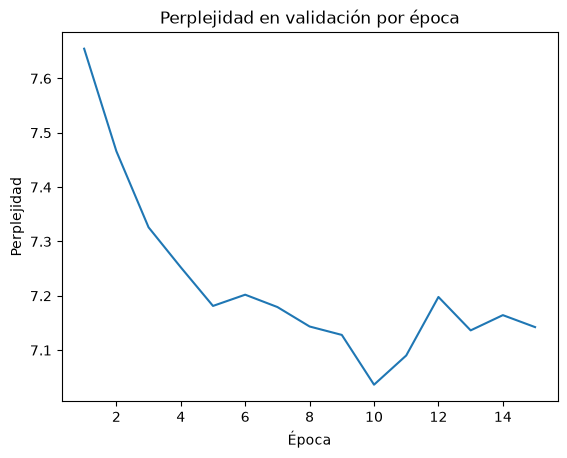

In [27]:
import pickle, os, matplotlib.pyplot as plt, seaborn as sns

if not history_ppl and os.path.exists('history_ppl.pkl'):
    with open('history_ppl.pkl', 'rb') as _f:
        history_ppl = pickle.load(_f)

if history_ppl:
    epoch_count = range(1, len(history_ppl) + 1)
    sns.lineplot(x=epoch_count, y=history_ppl)
    plt.xlabel('Época')
    plt.ylabel('Perplejidad')
    plt.title('Perplejidad en validación por época')
    plt.show()
else:
    print('No hay historia de perplejidad disponible.')


La perplejidad baja de ~7.65 en la primera época hasta ~7.04 en la décima, y luego oscila sin mejorar — el early stopping corta en la época 15. SimpleRNN con este corpus llega rápido a su límite.

### Comparación: SimpleRNN vs LSTM

Se entrena un modelo LSTM con 100 unidades (mismo optimizador rmsprop, mismo early stopping) para comparar la perplejidad de validación que alcanza cada arquitectura.

El LSTM con 100 unidades tiene ~66K parámetros, similar al SimpleRNN de 200 unidades (~65K). La comparación muestra si la arquitectura en sí aporta, más allá del tamaño del modelo.

In [ ]:
from keras.layers import LSTM as LSTMLayer

RETRAIN_LSTM = False  # Poner True para volver a entrenar desde cero
history_ppl_lstm = []

if RETRAIN_LSTM:
    model_lstm = Sequential([
        TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode='one_hot'),
                        input_shape=(None, 1)),
        LSTMLayer(100, return_sequences=True, dropout=0.1),
        Dense(vocab_size, activation='softmax'),
    ])
    model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    model_lstm.summary()

    import tensorflow as tf
    batch_size = 256
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X, y))
        .shuffle(10000)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    history_ppl_lstm = []
    model_lstm.fit(train_ds, epochs=20,
                   callbacks=[PplCallback(tokenized_sentences_val, history_ppl_lstm,
                                          save_path='my_model_lstm.keras')])
    with open('history_ppl_lstm.pkl', 'wb') as _f:
        pickle.dump(history_ppl_lstm, _f)
else:
    model_lstm = keras.models.load_model('my_model_lstm.keras')
    with open('history_ppl_lstm.pkl', 'rb') as _f:
        history_ppl_lstm = pickle.load(_f)
    print('Modelo LSTM cargado desde my_model_lstm.keras')

#### Curvas de perplejidad: SimpleRNN vs LSTM

Comparamos la evolución de la perplejidad de validación época a época para las dos arquitecturas.

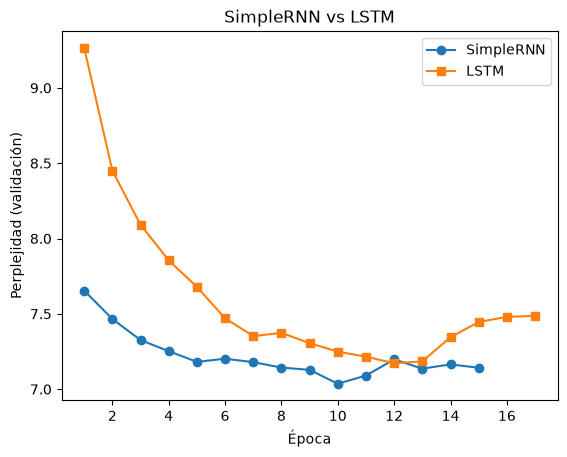

SimpleRNN — ppl mínima: 7.036 (época 10)
LSTM       — ppl mínima: 7.173 (época 12)


In [29]:
import pickle, os
import matplotlib.pyplot as plt
import seaborn as sns

if not history_ppl and os.path.exists('history_ppl.pkl'):
    with open('history_ppl.pkl', 'rb') as _f:
        history_ppl = pickle.load(_f)

fig, ax = plt.subplots()
ax.plot(range(1, len(history_ppl) + 1), history_ppl, marker='o', label='SimpleRNN')
ax.plot(range(1, len(history_ppl_lstm) + 1), history_ppl_lstm, marker='s', label='LSTM')
ax.set_xlabel('Época')
ax.set_ylabel('Perplejidad (validación)')
ax.set_title('SimpleRNN vs LSTM')
ax.legend()
plt.show()

print(f'SimpleRNN — ppl mínima: {min(history_ppl):.3f} (época {history_ppl.index(min(history_ppl))+1})')
print(f'LSTM       — ppl mínima: {min(history_ppl_lstm):.3f} (época {history_ppl_lstm.index(min(history_ppl_lstm))+1})')


In [30]:
# El modelo ya fue cargado arriba (en la celda de definición). El callback guardó my_model.keras y aquí se recarga
if RETRAIN:
    model = keras.models.load_model('my_model.keras')



### Predicción del próximo caracter

In [31]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [32]:
# import gradio as gr

# def model_response(human_text):

#     # Encodeamos
#     encoded = [char2idx[ch] for ch in human_text.lower() ]
#     # Si tienen distinto largo
#     encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

#     # Predicción softmax
#     y_hat = np.argmax(model.predict(encoded)[0,-1,:])


#     # Debemos buscar en el vocabulario el caracter
#     # que corresopnde al indice (y_hat) predicho por le modelo
#     out_word = ''
#     out_word = idx2char[y_hat]

#     # Agrego la palabra a la frase predicha
#     return human_text + out_word

# iface = gr.Interface(
#     fn=model_response,
#     inputs=["textbox"],
#     outputs="text")

# iface.launch(debug=True)

### Greedy search

El resultado es `habia una vez de la cabeza de la cabeza de`, cae en loop al tercer token.

In [33]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [34]:
input_text='habia una vez'

generate_seq(model, input_text, max_length=max_context_size, n_words=30)

I0000 00:00:1786048187.422296   84680 service.cc:153] XLA service 0x73356b7d8420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786048187.423270   84680 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1650, Compute Capability 7.5 (Driver: 12.9.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.3.0)
I0000 00:00:1786048187.834721   84680 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786048190.304757   84680 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


'habia una vez de la cabeza de la cabeza de '

### Beam search

El beam determinista genera continuaciones con sentido: los beams divergen ya en el cuarto token (`como` vs `de`), lo que muestra que el modelo aprendió más de una continuación plausible para el mismo contexto.

Con temperatura baja (0.5) el estocástico converge casi igual que el greedy (`de una cosa de los ojos de`). A temperatura 1.0 los beams divergen más tarde pero comparten prefijo largo (`en su padre en el cuero de`). A temperatura 1.5 aparece variedad real desde el inicio, aunque algunas palabras pierden coherencia (`orido`).

In [35]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [36]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [37]:
# Beam search 
salidas = beam_search(model, num_beams=10, num_words=30, input='habia una vez')

print('=== Beam search determinista ===')
for i, seq in enumerate(salidas):
    print(f'Beam {i+1}: {decode(seq)}')


=== Beam search determinista ===
Beam 1: habia una vez como una contestó:

--mariano
Beam 2: habia una vez de los indios, todos los indi
Beam 3: habia una vez de los indios se había hecho 
Beam 4: habia una vez como una contestó:

--no era 
Beam 5: habia una vez de los indios, todos los homb
Beam 6: habia una vez de los indios, todos los ojos
Beam 7: habia una vez como una contestó:

--no esta
Beam 8: habia una vez como una contestó:

--no está
Beam 9: habia una vez como una contestó:

--no por 
Beam 10: habia una vez de los indios se había como e


In [38]:
# Efecto de la temperatura
print('=== Beam search estocástico ===')
for temp in [0.5, 1.0, 1.5]:
    salidas_sto = beam_search(model, num_beams=5, num_words=30,
                              input='habia una vez', temp=temp, mode='sto')
    print(f'\nTemperatura = {temp}')
    for i, seq in enumerate(salidas_sto):
        print(f'  Beam {i+1}: {decode(seq)}')


=== Beam search estocástico ===

Temperatura = 0.5
  Beam 1: habia una vez de una cosa de los ojos de la
  Beam 2: habia una vez de una cosa de los ojos de lo
  Beam 3: habia una vez de una cosa de los ojos de un
  Beam 4: habia una vez de una cosa de los ojos de la
  Beam 5: habia una vez de una cosa de los ojos de la

Temperatura = 1.0
  Beam 1: habia una vez en su padre en el cuero de lo
  Beam 2: habia una vez en su padre en el cuero de bu
  Beam 3: habia una vez en su padre en el cuero de la
  Beam 4: habia una vez en su padre en el cuero de la
  Beam 5: habia una vez en su padre en el cuero de la

Temperatura = 1.5
  Beam 1: habia una vez y el orido de la cabeza, quer
  Beam 2: habia una vez y el orido de la cabeza, qued
  Beam 3: habia una vez y el orido de la cabeza, que 
  Beam 4: habia una vez y el orido de la cabeza, que

  Beam 5: habia una vez y el orido de la cabeza, que:


### Conclusiones

**SimpleRNN (200 unidades, ~65K parámetros):** perplejidad mínima = 7.04 (época 10), early stopping en época 15.

**LSTM (100 unidades, ~66K parámetros):** perplejidad mínima = 7.17 (época 12), early stopping en época 17.

Con igual cantidad de parámetros, el SimpleRNN logró una pequeña mejor perplejidad que el LSTM en este corpus. En ese contexto el SimpleRNN con más unidades tiene más capacidad de representación que el LSTM con menos unidades, y la ventana de 100 caracteres es suficiente para capturar las dependencias relevantes sin necesitar la memoria selectiva a largo plazo que ofrece el LSTM.

Ambos modelos capturan bien los patrones locales: generan texto con ortografía correcta y reproducen frases del corpus (`de los indios`, `contestó:`, `los ojos de`). Greedy cae en loop rápido (`cabeza de la cabeza de`). Beam determinista mantiene coherencia y los beams divergen entre sí mostrando variedad. Beam estocástico con temperatura alta (1.5) introduce variedad real a costa de coherencia semántica.